In [3]:
import os
print(os.getcwd())

c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\notebooks\eda


In [ ]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "raw", "compcars")

print("Project root:", PROJECT_ROOT)
print("Misc folder contents:", os.listdir(os.path.join(DATA_ROOT, "misc")))

Project root: c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning
Misc folder contents: ['attributes.txt', 'car_type.mat', 'make_model_name.mat']


In [7]:
from scipy.io import loadmat

mat = loadmat(os.path.join(DATA_ROOT, "misc", "make_model_name.mat"))
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'make_names', 'model_names'])


In [9]:
sample_key = [k for k in mat if not k.startswith("__")][0]  # grab first real key
print(mat[sample_key][:5])

[[array(['ABT'], dtype='<U3')]
 [array(['BAC'], dtype='<U3')]
 [array(['Conquest'], dtype='<U8')]
 [array(['DS'], dtype='<U2')]
 [array(['Dacia'], dtype='<U5')]]


In [8]:
for key in mat:
    if not key.startswith("__"):
        print(key, type(mat[key]), mat[key].shape if hasattr(mat[key], 'shape') else '')

make_names <class 'numpy.ndarray'> (163, 1)
model_names <class 'numpy.ndarray'> (2004, 1)


In [10]:
make_names = [item[0][0] for item in mat[sample_key]]
print(make_names[:10])
print("Total makes:", len(make_names))

[np.str_('ABT'), np.str_('BAC'), np.str_('Conquest'), np.str_('DS'), np.str_('Dacia'), np.str_('Fisker'), np.str_('GMC'), np.str_('Gumpert'), np.str_('Hennessey'), np.str_('Icona')]
Total makes: 163


In [11]:
make_id_to_name = {i+1: name for i, name in enumerate(make_names)}  # CompCars IDs are usually 1-indexed
print(list(make_id_to_name.items())[:5])

[(1, np.str_('ABT')), (2, np.str_('BAC')), (3, np.str_('Conquest')), (4, np.str_('DS')), (5, np.str_('Dacia'))]


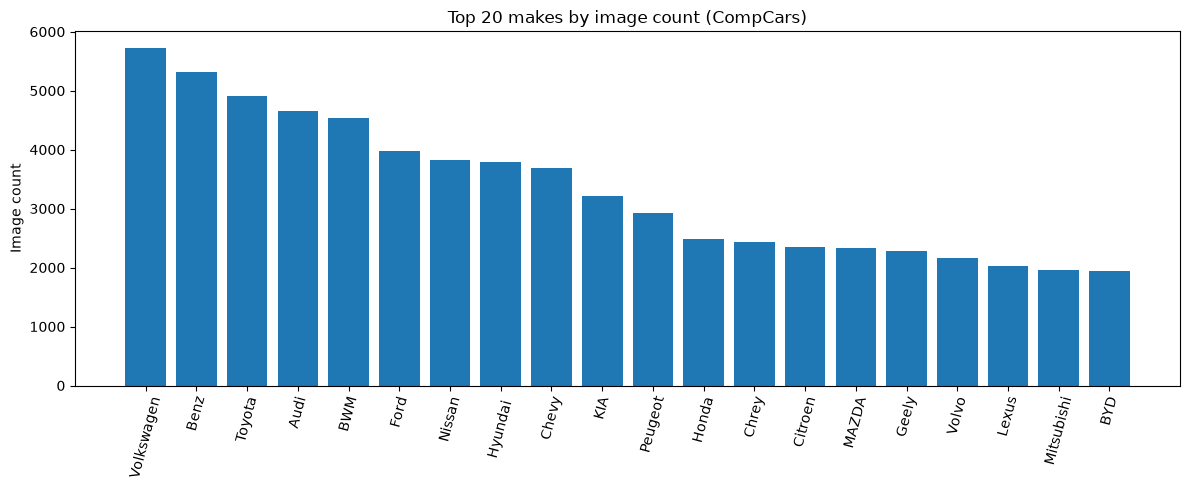

In [12]:
import matplotlib.pyplot as plt

image_root = os.path.join(DATA_ROOT, "image")
counts = {}
for make_id in os.listdir(image_root):
    make_path = os.path.join(image_root, make_id)
    total = sum(len(files) for _, _, files in os.walk(make_path))
    name = make_id_to_name.get(int(make_id), make_id)
    counts[name] = total

# sort and plot top 20
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20])
plt.figure(figsize=(12, 5))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xticks(rotation=75)
plt.ylabel("Image count")
plt.title("Top 20 makes by image count (CompCars)")
plt.tight_layout()
plt.show()

Model Names

In [13]:
for key in mat:
    if not key.startswith("__"):
        print(key)

make_names
model_names


In [14]:
model_names = [item[0][0] if len(item[0]) > 0 else "" for item in mat['model_names']]
print(model_names[:10])
print("Total models:", len(model_names))

[np.str_('Audi A3 hatchback'), np.str_('Audi A4L'), np.str_('Audi A6L'), np.str_('Audi Q3'), np.str_('Audi Q5'), '', '', '', np.str_('Audi A6'), '']
Total models: 2004


In [15]:
model_counts = {}

for make_id in os.listdir(image_root):
    make_path = os.path.join(image_root, make_id)
    make_name = make_id_to_name.get(int(make_id), make_id)
    for model_id in os.listdir(make_path):
        model_path = os.path.join(make_path, model_id)
        total = sum(len(files) for _, _, files in os.walk(model_path))
        # model_names is indexed globally, not per-make, so this may need adjustment
        # depending on how CompCars structures the ID space - check this
        label = f"{make_name} - {model_id}"
        model_counts[label] = total

print("Total distinct models:", len(model_counts))

Total distinct models: 1716


Models with <10 images: 92
Median images per model: 95.0
Max images per model: 303


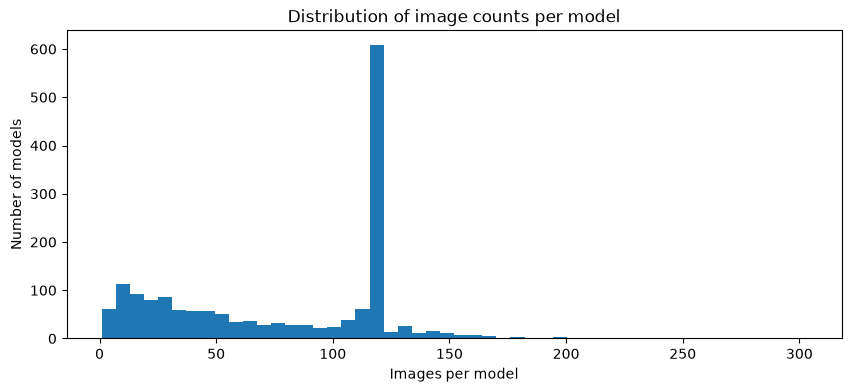

In [16]:
import numpy as np

counts_array = np.array(list(model_counts.values()))
print("Models with <10 images:", (counts_array < 10).sum())
print("Median images per model:", np.median(counts_array))
print("Max images per model:", counts_array.max())

plt.figure(figsize=(10, 4))
plt.hist(counts_array, bins=50)
plt.xlabel("Images per model")
plt.ylabel("Number of models")
plt.title("Distribution of image counts per model")
plt.show()

In [20]:
max_model = max(model_counts, key=model_counts.get)
print(max_model, model_counts[max_model])

Buck - 196 303


In [21]:
print(model_names[196])

EXCELLE  XT


C:\Users\nicho\AppData\Local\Temp\ipykernel_5372\1525763209.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(counts_list, vert=True)


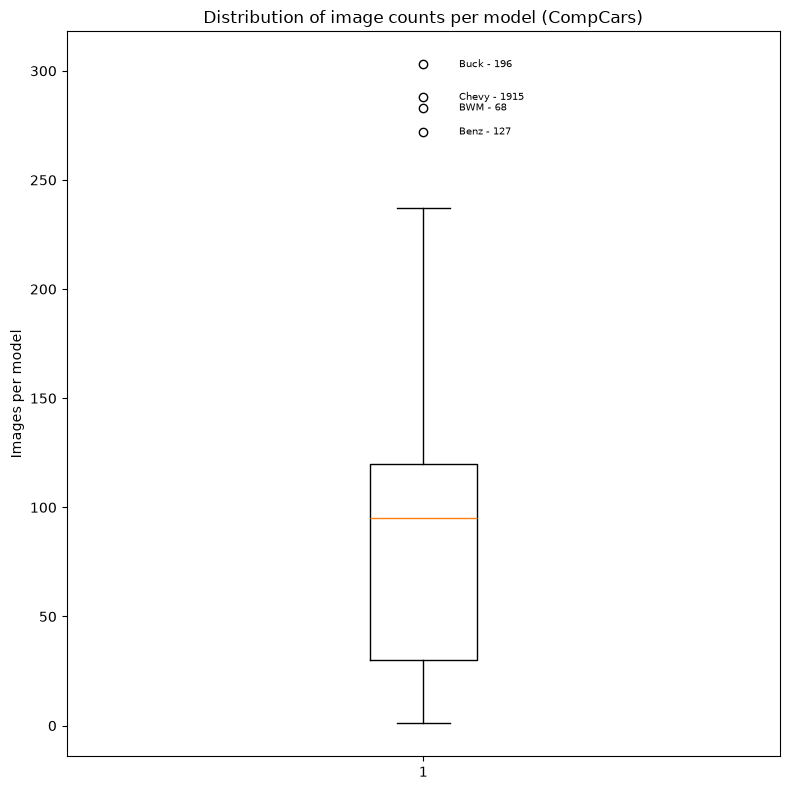

In [ ]:
counts_list = list(model_counts.values())
names_list = list(model_counts.keys())

fig, ax = plt.subplots(figsize=(8, 8))
bp = ax.boxplot(counts_list, vert=True)


q1 = np.percentile(counts_list, 25)
q3 = np.percentile(counts_list, 75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

for name, count in zip(names_list, counts_list):
    if count > upper_bound or count < lower_bound:
        ax.annotate(
            name,
            xy=(1, count),
            xytext=(1.05, count),
            fontsize=7,
            va="center",
            rotation=0
        )

ax.set_ylabel("Images per model")
ax.set_title("Distribution of image counts per model (CompCars)")
plt.tight_layout()
plt.show()

Investigating make_model_name.mat

In [23]:
car_type_mat = loadmat(os.path.join(DATA_ROOT, "misc", "car_type.mat"))
print(car_type_mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'types'])


In [24]:
for key in car_type_mat:
    if not key.startswith("__"):
        print(key, type(car_type_mat[key]), car_type_mat[key].shape)

types <class 'numpy.ndarray'> (1, 12)


In [25]:
sample_key = [k for k in car_type_mat if not k.startswith("__")][0]
print(car_type_mat[sample_key][:20])

[[array(['MPV'], dtype='<U3') array(['SUV'], dtype='<U3')
  array(['sedan'], dtype='<U5') array(['hatchback'], dtype='<U9')
  array(['minibus'], dtype='<U7') array(['fastback'], dtype='<U8')
  array(['estate'], dtype='<U6') array(['pickup'], dtype='<U6')
  array(['hardtop convertible'], dtype='<U19')
  array(['sports'], dtype='<U6') array(['crossover'], dtype='<U9')
  array(['convertible'], dtype='<U11')]]


In [26]:
car_type_array = car_type_mat[sample_key].flatten()
print("Total entries:", len(car_type_array))
print("Non-zero / labeled entries:", np.count_nonzero(car_type_array))
print("Unique body type codes:", np.unique(car_type_array))

Total entries: 12
Non-zero / labeled entries: 12
Unique body type codes: [array(['MPV'], dtype='<U3') array(['SUV'], dtype='<U3')
 array(['convertible'], dtype='<U11') array(['crossover'], dtype='<U9')
 array(['estate'], dtype='<U6') array(['fastback'], dtype='<U8')
 array(['hardtop convertible'], dtype='<U19')
 array(['hatchback'], dtype='<U9') array(['minibus'], dtype='<U7')
 array(['pickup'], dtype='<U6') array(['sedan'], dtype='<U5')
 array(['sports'], dtype='<U6')]


In [28]:
with open(os.path.join(DATA_ROOT, "misc", "attributes.txt")) as f:
    lines = f.readlines()

print(len(lines))
for line in lines[:10]:
    print(line.strip())

1717
model_id maximum_speed displacement door_number seat_number type
1 235 1.8 5 5 4
2 220 1.8 4 5 3
3 228 2.0 4 5 3
4 230 2.0 5 5 2
5 234 3.0 5 5 2
9 0 0.0 0 0 0
11 242 1.8 4 5 3
12 250 4.2 2 4 3
13 250 4.0 5 4 6


In [30]:
import pandas as pd

# adjust column names/widths once you see the raw format from the print above
attrs_df = pd.read_csv(
    os.path.join(DATA_ROOT, "misc", "attributes.txt"),
    sep=r"\s+",
    header=None,
    names=["model_id", "max_speed", "displacement", "door_num", "seat_num", "car_type"]
)
print(attrs_df.head())
print(attrs_df.shape)

   model_id      max_speed  displacement     door_num     seat_num car_type
0  model_id  maximum_speed  displacement  door_number  seat_number     type
1         1            235           1.8            5            5        4
2         2            220           1.8            4            5        3
3         3            228           2.0            4            5        3
4         4            230           2.0            5            5        2
(1717, 6)


In [37]:
print("Total models with attributes:", len(attrs_df))
print("Car type value counts:")
print(attrs_df["car_type"].value_counts())

Total models with attributes: 1717
Car type value counts:
car_type
0.0     748
3.0     290
2.0     200
4.0     158
5.0      71
1.0      60
10.0     56
8.0      46
6.0      22
9.0      22
12.0     16
7.0      14
11.0     13
Name: count, dtype: int64


In [39]:
print(len(type_names))
print(type_names)

12
[np.str_('MPV'), np.str_('SUV'), np.str_('sedan'), np.str_('hatchback'), np.str_('minibus'), np.str_('fastback'), np.str_('estate'), np.str_('pickup'), np.str_('hardtop convertible'), np.str_('sports'), np.str_('crossover'), np.str_('convertible')]


In [40]:
def map_car_type(code):
    if pd.isna(code):
        return "unknown/malformed"
    code = int(code)  # <-- this line converts float to int before indexing
    if code == 0:
        return "unlabeled"
    return type_names[code - 1]

attrs_df["car_type_name"] = attrs_df["car_type"].apply(map_car_type)
print(attrs_df["car_type_name"].value_counts())

car_type_name
unlabeled              748
sedan                  290
SUV                    200
hatchback              158
minibus                 71
MPV                     60
sports                  56
pickup                  46
fastback                22
hardtop convertible     22
convertible             16
estate                  14
crossover               13
unknown/malformed        1
Name: count, dtype: int64


Resolution of images


In [42]:
import random
from PIL import Image

# collect all image paths first (or a large subset if this is slow)
all_image_paths = []
for root, dirs, files in os.walk(image_root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_image_paths.append(os.path.join(root, f))

print("Total images found:", len(all_image_paths))

# sample a manageable subset
sample_size = 500
sample_paths = random.sample(all_image_paths, min(sample_size, len(all_image_paths)))

Total images found: 136726


In [43]:
resolutions = []
corrupted = []

for path in sample_paths:
    try:
        with Image.open(path) as img:
            resolutions.append({
                "path": path,
                "width": img.width,
                "height": img.height,
                "aspect_ratio": round(img.width / img.height, 2),
                "mode": img.mode
            })
    except Exception as e:
        corrupted.append((path, str(e)))

print("Corrupted/unreadable images in sample:", len(corrupted))

Corrupted/unreadable images in sample: 0


In [44]:
res_df = pd.DataFrame(resolutions)

print(res_df[["width", "height"]].describe())
print("\nMost common resolutions:")
print(res_df.groupby(["width", "height"]).size().sort_values(ascending=False).head(10))
print("\nColor mode counts:")
print(res_df["mode"].value_counts())

             width      height
count   500.000000  500.000000
mean    853.686000  585.794000
std      61.549493   49.977826
min     700.000000  416.000000
25%     800.000000  567.000000
50%     800.000000  567.000000
75%     908.000000  626.000000
max    1024.000000  718.000000

Most common resolutions:
width  height
800    567       191
908    626       178
800    552        28
       484        20
909    627        14
1024   718        12
800    500         6
       482         6
950    539         4
800    417         4
dtype: int64

Color mode counts:
mode
RGB    500
Name: count, dtype: int64


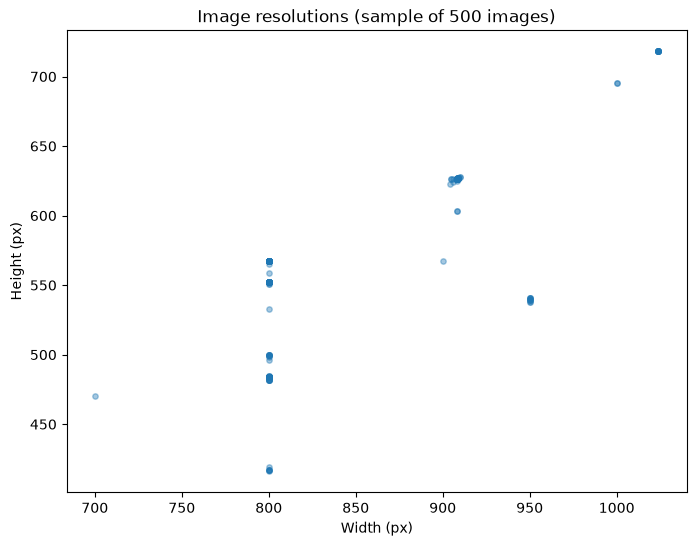

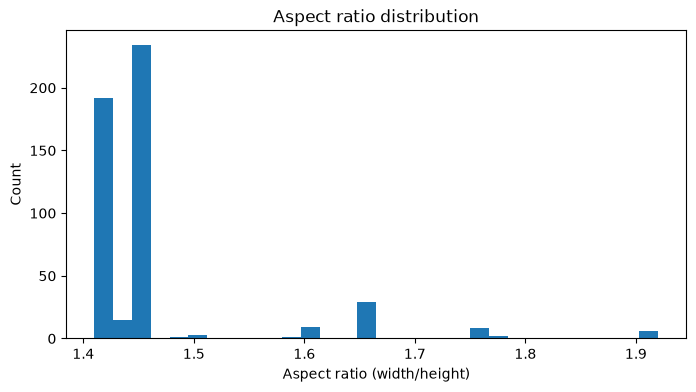

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(res_df["width"], res_df["height"], alpha=0.4, s=15)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title(f"Image resolutions (sample of {len(res_df)} images)")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(res_df["aspect_ratio"], bins=30)
plt.xlabel("Aspect ratio (width/height)")
plt.ylabel("Count")
plt.title("Aspect ratio distribution")
plt.show()

Images resolution is pretty consistent and are all RGB. Can standardize into one resize target if using CNN. 

Image viewpoints

In [47]:
sample_label_dir = os.path.join(DATA_ROOT, "label")
for root, dirs, files in os.walk(sample_label_dir):
    if files:
        sample_label_path = os.path.join(root, files[0])
        break

with open(sample_label_path) as f:
    print(f.read())

1
1
124 33 674 480



In [48]:
import random

label_root = os.path.join(DATA_ROOT, "label")
all_label_paths = []
for root, dirs, files in os.walk(label_root):
    for f in files:
        if f.endswith(".txt"):
            all_label_paths.append(os.path.join(root, f))

sample_labels = random.sample(all_label_paths, 10)
for path in sample_labels:
    with open(path) as f:
        lines = f.read().strip().split("\n")
    print(lines[0], "|", lines[1], "|", lines[2] if len(lines) > 2 else "")

4 | 1 | 144 176 764 600
1 | 1 | 158 98 661 442
4 | 1 | 221 301 581 474
4 | 1 | 112 209 814 527
5 | 1 | 106 95 708 515
4 | 1 | 189 271 793 595
5 | 1 | 40 175 775 492
4 | 1 | 44 88 745 467
4 | 1 | 82 219 940 549
4 | 1 | 70 140 716 496


In [49]:
from collections import Counter

viewpoint_codes = []
for path in all_label_paths:
    with open(path) as f:
        lines = f.read().strip().split("\n")
    if lines and lines[0].strip():
        viewpoint_codes.append(int(lines[0]))

viewpoint_counts = Counter(viewpoint_codes)
print(viewpoint_counts)

Counter({4: 49301, 5: 31150, 3: 23551, 1: 18431, 2: 13513, -1: 780})


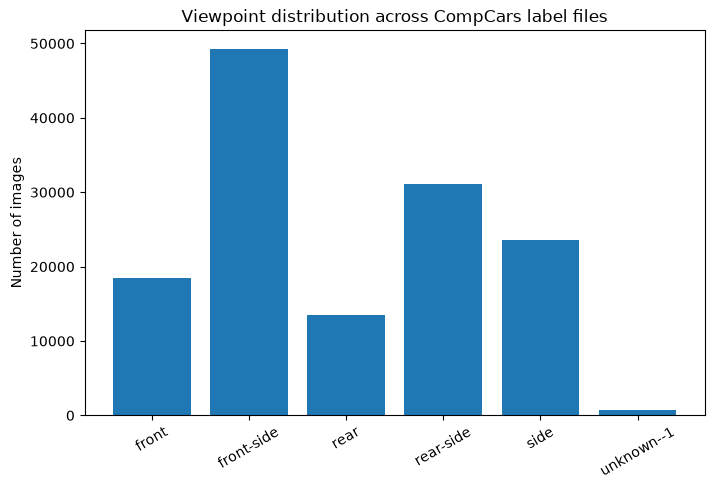

{'front': 18431, 'front-side': 49301, 'rear': 13513, 'rear-side': 31150, 'side': 23551, 'unknown--1': 780}


In [50]:
viewpoint_names = {1: "front", 2: "rear", 3: "side", 4: "front-side", 5: "rear-side"}

named_counts = {viewpoint_names.get(k, f"unknown-{k}"): v for k, v in viewpoint_counts.items()}

plt.figure(figsize=(8, 5))
plt.bar(named_counts.keys(), named_counts.values())
plt.ylabel("Number of images")
plt.title("Viewpoint distribution across CompCars label files")
plt.xticks(rotation=30)
plt.show()

print(named_counts)

Viewpoints of same car?

In [53]:
sample_year_folders = []
for make_id in os.listdir(image_root)[:5]:
    make_path = os.path.join(image_root, make_id)
    for model_id in os.listdir(make_path):
        model_path = os.path.join(make_path, model_id)
        for year in os.listdir(model_path):
            year_path = os.path.join(model_path, year)
            files = os.listdir(year_path)
            sample_year_folders.append((year_path, len(files)))

for path, count in sample_year_folders[:20]:
    print(count, path)

18 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1101\2011
9 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1102\2011
3 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1102\2012
21 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1103\2011
3 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1103\2013
4 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1103\2015
2 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1104\2010
7 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1105\2011
4 c:\Users\nicho\Vehicle-Metadata-Identification-Using-Machine-Learning\data\raw\compcars\image\1\1106\2009
3 c:\Users\nicho\Vehicle-M

Compcars does have multiple viewpoints of the same car.